In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('titanic.csv')

In [3]:
df.shape

(891, 12)

In [4]:
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [5]:

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count' : missing,
    'Missing %'     : missing_pct
})

print(missing_df[missing_df['Missing Count'] > 0])

          Missing Count  Missing %
Age                 177  19.865320
Cabin               687  77.104377
Embarked              2   0.224467


In [7]:
print(df['Survived'].value_counts())

Survived
0    549
1    342
Name: count, dtype: int64


In [8]:
print(f"\nSurvival Rate: {df['Survived'].mean()*100:.2f}%")


Survival Rate: 38.38%


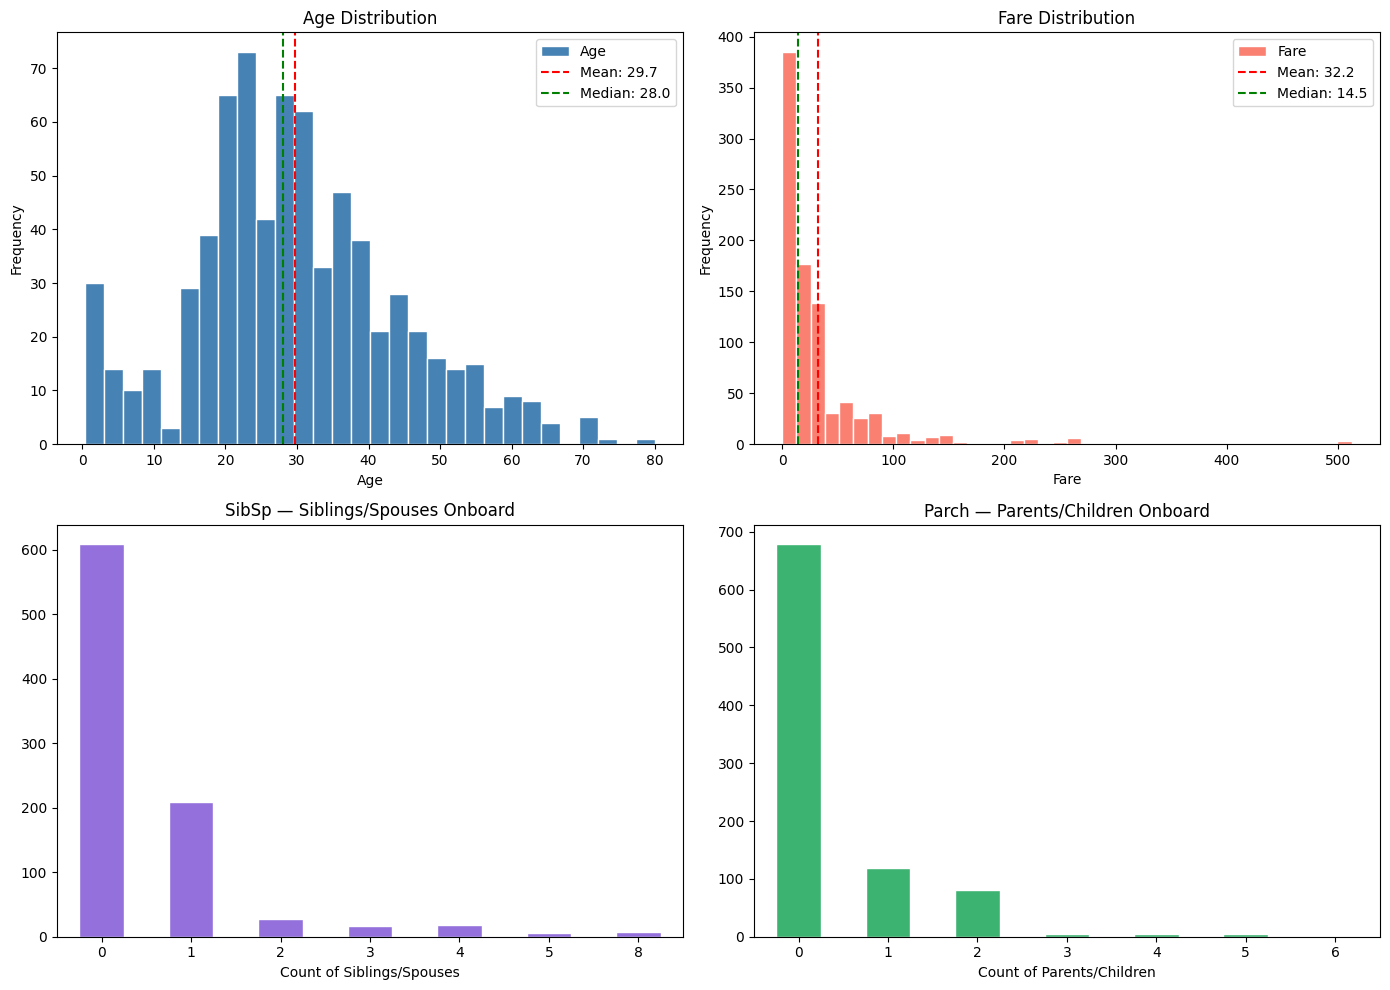

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Age distribution
df['Age'].plot(kind='hist', bins=30, ax=axes[0][0],
               color='steelblue', edgecolor='white',
               title='Age Distribution')
axes[0][0].set_xlabel('Age')
axes[0][0].axvline(df['Age'].mean(), color='red',
                   linestyle='--', label=f"Mean: {df['Age'].mean():.1f}")
axes[0][0].axvline(df['Age'].median(), color='green',
                   linestyle='--', label=f"Median: {df['Age'].median():.1f}")
axes[0][0].legend()

# Fare distribution
df['Fare'].plot(kind='hist', bins=40, ax=axes[0][1],
                color='salmon', edgecolor='white',
                title='Fare Distribution')
axes[0][1].set_xlabel('Fare')
axes[0][1].axvline(df['Fare'].mean(), color='red',
                   linestyle='--', label=f"Mean: {df['Fare'].mean():.1f}")
axes[0][1].axvline(df['Fare'].median(), color='green',
                   linestyle='--', label=f"Median: {df['Fare'].median():.1f}")
axes[0][1].legend()

# SibSp distribution
df['SibSp'].value_counts().sort_index().plot(kind='bar', ax=axes[1][0],
    color='mediumpurple', edgecolor='white',
    title='SibSp — Siblings/Spouses Onboard')
axes[1][0].set_xlabel('Count of Siblings/Spouses')
axes[1][0].tick_params(rotation=0)

# Parch distribution
df['Parch'].value_counts().sort_index().plot(kind='bar', ax=axes[1][1],
    color='mediumseagreen', edgecolor='white',
    title='Parch — Parents/Children Onboard')
axes[1][1].set_xlabel('Count of Parents/Children')
axes[1][1].tick_params(rotation=0)

plt.tight_layout()
plt.show()


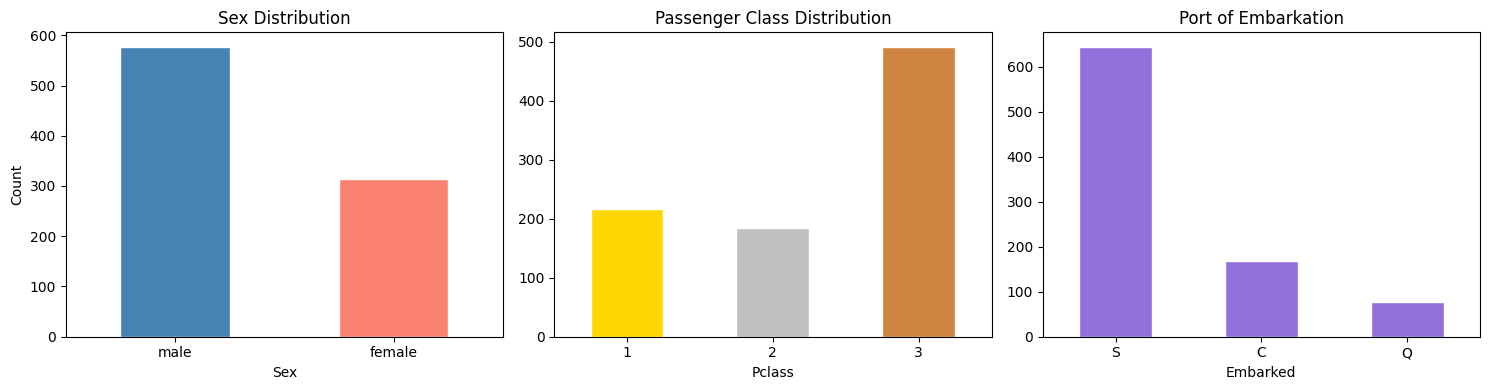

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Sex
df['Sex'].value_counts().plot(kind='bar', ax=axes[0],
    color=['steelblue','salmon'],
    title='Sex Distribution', edgecolor='white')
axes[0].tick_params(rotation=0)
axes[0].set_ylabel('Count')

# Pclass
df['Pclass'].value_counts().sort_index().plot(kind='bar', ax=axes[1],
    color=['gold','silver','peru'],
    title='Passenger Class Distribution', edgecolor='white')
axes[1].tick_params(rotation=0)

# Embarked
df['Embarked'].value_counts().plot(kind='bar', ax=axes[2],
    color='mediumpurple',
    title='Port of Embarkation', edgecolor='white')
axes[2].tick_params(rotation=0)

plt.tight_layout()
plt.show()

In [11]:
df.groupby('Sex')['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [12]:
df.groupby('Pclass')['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [13]:
df.groupby('Embarked')['Survived'].mean()

Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64

Correlation with Survived:
Pclass     -0.338481
Age        -0.077221
SibSp      -0.035322
Parch       0.081629
Fare        0.257307
Survived    1.000000
Name: Survived, dtype: float64



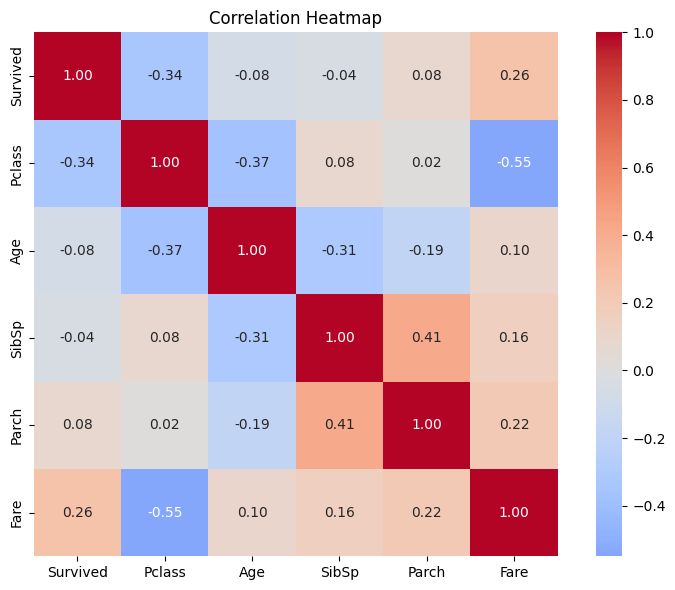

In [14]:
import seaborn as sns
# Correlation of all numerical features with Survived

corr = df[['Survived','Pclass','Age','SibSp',
           'Parch','Fare']].corr()

print("Correlation with Survived:")
print(corr['Survived'].sort_values())
print()

# Heatmap — see all correlations at once
plt.figure(figsize=(8,6))
sns.heatmap(corr, 
            annot=True,        # show numbers inside boxes
            fmt='.2f',         # 2 decimal places
            cmap='coolwarm',   # red=positive, blue=negative
            center=0,
            square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [15]:
df = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

print("Columns remaining:", df.columns.tolist())
print("Shape:", df.shape)

Columns remaining: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
Shape: (891, 8)


In [16]:
df['Age']=df['Age'].fillna(df['Age'].median())

df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])

print("Missing Value after imputation:", df.isnull().sum())

Missing Value after imputation: Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [17]:
df['FamilySize']= df['SibSp'] + df['Parch'] + 1

df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

print("New features added:")
print(df[['SibSp','Parch','FamilySize','IsAlone']].head(10))

New features added:
   SibSp  Parch  FamilySize  IsAlone
0      1      0           2        0
1      1      0           2        0
2      0      0           1        1
3      1      0           2        0
4      0      0           1        1
5      0      0           1        1
6      0      0           1        1
7      3      1           5        0
8      0      2           3        0
9      1      0           2        0


In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Define column groups
numerical_cols   = ['Pclass', 'Age', 'Fare', 'SibSp',
                    'Parch', 'FamilySize', 'IsAlone']
categorical_cols = ['Sex', 'Embarked']

# ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(),numerical_cols),
        ('cat', OneHotEncoder(drop='first',sparse_output=False),  categorical_cols),
    ],
    remainder='drop'
)



In [19]:
X = df.drop('Survived', axis=1)
y = df['Survived']

In [20]:
X_processed = preprocessor.fit_transform(X)

In [21]:
print("Shape after encoding:", X_processed.shape)

# 2. See the actual processed values
print("\nFirst 5 rows after encoding:")
print(X_processed[:5])

# 3. See it as a readable DataFrame with column names
num_feature_names = numerical_cols
cat_feature_names = (preprocessor
                     .named_transformers_['cat']
                     .get_feature_names_out(categorical_cols)
                     .tolist())

all_feature_names = num_feature_names + cat_feature_names

df_processed = pd.DataFrame(X_processed, 
                             columns=all_feature_names)

print("\nProcessed DataFrame:")
print(df_processed.head())

Shape after encoding: (891, 10)

First 5 rows after encoding:
[[ 0.82737724 -0.56573646 -0.50244517  0.43279337 -0.47367361  0.05915988
  -1.2316449   1.          0.          1.        ]
 [-1.56610693  0.66386103  0.78684529  0.43279337 -0.47367361  0.05915988
  -1.2316449   0.          0.          0.        ]
 [ 0.82737724 -0.25833709 -0.48885426 -0.4745452  -0.47367361 -0.56097483
   0.81192233  0.          0.          1.        ]
 [-1.56610693  0.4333115   0.42073024  0.43279337 -0.47367361  0.05915988
  -1.2316449   0.          0.          1.        ]
 [ 0.82737724  0.4333115  -0.48633742 -0.4745452  -0.47367361 -0.56097483
   0.81192233  1.          0.          1.        ]]

Processed DataFrame:
     Pclass       Age      Fare     SibSp     Parch  FamilySize   IsAlone  \
0  0.827377 -0.565736 -0.502445  0.432793 -0.473674    0.059160 -1.231645   
1 -1.566107  0.663861  0.786845  0.432793 -0.473674    0.059160 -1.231645   
2  0.827377 -0.258337 -0.488854 -0.474545 -0.473674   -0.56

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y,
    test_size    = 0.2,       # 80% train, 20% test
    random_state = 42,        # reproducibility
    stratify     = y          # maintain 38/62 class ratio
)

print("Training samples  :", X_train.shape[0])
print("Testing samples   :", X_test.shape[0])
print("\nTraining features :", X_train.shape[1])

print("\nClass distribution in Train:")
print(pd.Series(y_train).value_counts())

print("\nClass distribution in Test:")
print(pd.Series(y_test).value_counts())

Training samples  : 712
Testing samples   : 179

Training features : 10

Class distribution in Train:
Survived
0    439
1    273
Name: count, dtype: int64

Class distribution in Test:
Survived
0    110
1     69
Name: count, dtype: int64


   LOGISTIC REGRESSION RESULTS
Accuracy  : 80.45%
Precision : 78.33%
Recall    : 68.12%
F1 Score  : 72.87%
AUC-ROC   : 0.8509

Classification Report:
              precision    recall  f1-score   support

Not Survived       0.82      0.88      0.85       110
    Survived       0.78      0.68      0.73        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



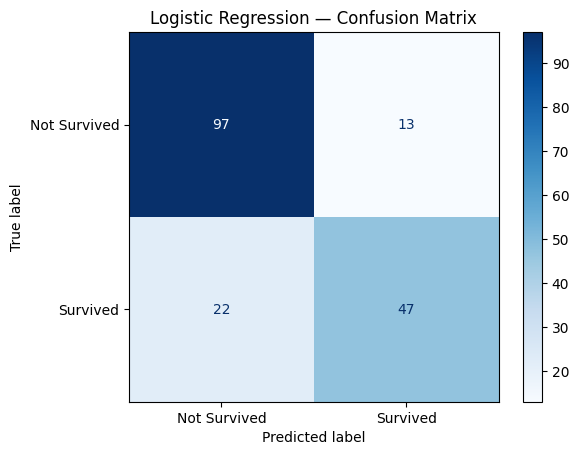

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay,
                             classification_report)
import matplotlib.pyplot as plt

# ── TRAIN ────────────────────────────────────────────────────
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# ── PREDICT ──────────────────────────────────────────────────
y_pred      = lr_model.predict(X_test)        # class labels (0 or 1)
y_proba     = lr_model.predict_proba(X_test)[:, 1]  # probabilities

# ── METRICS ──────────────────────────────────────────────────
print("=" * 40)
print("   LOGISTIC REGRESSION RESULTS")
print("=" * 40)
print(f"Accuracy  : {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"Precision : {precision_score(y_test, y_pred)*100:.2f}%")
print(f"Recall    : {recall_score(y_test, y_pred)*100:.2f}%")
print(f"F1 Score  : {f1_score(y_test, y_pred)*100:.2f}%")
print(f"AUC-ROC   : {roc_auc_score(y_test, y_proba):.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Not Survived', 'Survived']))

# ── CONFUSION MATRIX ─────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                    display_labels=['Not Survived','Survived'])
disp.plot(cmap='Blues')
plt.title('Logistic Regression — Confusion Matrix')
plt.show()

      RANDOM FOREST RESULTS
Accuracy  : 80.45%
Precision : 76.56%
Recall    : 71.01%
F1 Score  : 73.68%
AUC-ROC   : 0.8337

Classification Report:
              precision    recall  f1-score   support

Not Survived       0.83      0.86      0.84       110
    Survived       0.77      0.71      0.74        69

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



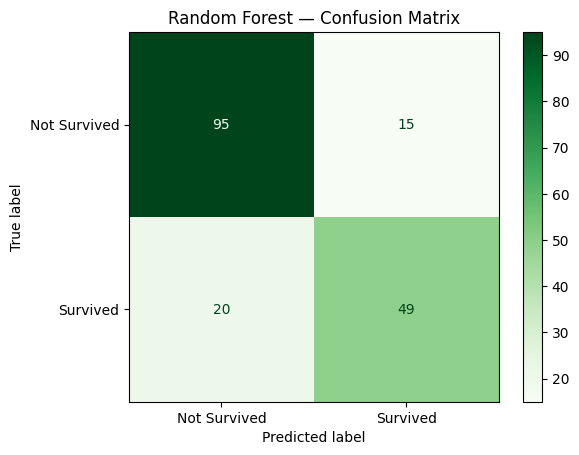

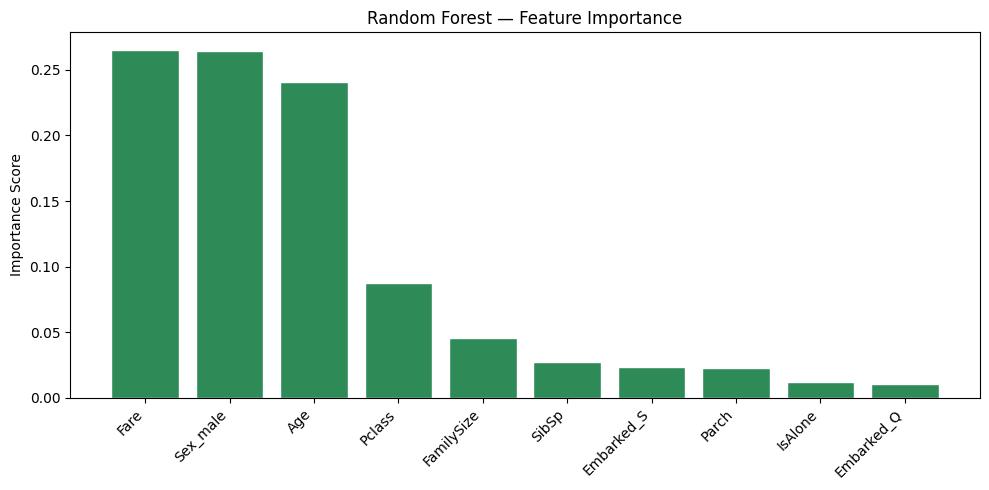


Feature Importance Ranking:
   Feature  Importance
      Fare    0.265381
  Sex_male    0.264484
       Age    0.240693
    Pclass    0.087284
FamilySize    0.045739
     SibSp    0.027462
Embarked_S    0.023650
     Parch    0.022622
   IsAlone    0.012100
Embarked_Q    0.010585


In [24]:
from sklearn.ensemble import RandomForestClassifier

# ── TRAIN ────────────────────────────────────────────────────
rf_model = RandomForestClassifier(n_estimators=100, 
                                   random_state=42)
rf_model.fit(X_train, y_train)

# ── PREDICT ──────────────────────────────────────────────────
y_pred  = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

# ── METRICS ──────────────────────────────────────────────────
print("=" * 40)
print("      RANDOM FOREST RESULTS")
print("=" * 40)
print(f"Accuracy  : {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"Precision : {precision_score(y_test, y_pred)*100:.2f}%")
print(f"Recall    : {recall_score(y_test, y_pred)*100:.2f}%")
print(f"F1 Score  : {f1_score(y_test, y_pred)*100:.2f}%")
print(f"AUC-ROC   : {roc_auc_score(y_test, y_proba):.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Not Survived', 'Survived']))

# ── CONFUSION MATRIX ─────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                    display_labels=['Not Survived','Survived'])
disp.plot(cmap='Greens')
plt.title('Random Forest — Confusion Matrix')
plt.show()

# ── FEATURE IMPORTANCE ───────────────────────────────────────
feature_names = (numerical_cols + 
                 preprocessor
                 .named_transformers_['cat']
                 .get_feature_names_out(categorical_cols)
                 .tolist())

importance_df = pd.DataFrame({
    'Feature'   : feature_names,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(importance_df['Feature'], 
        importance_df['Importance'],
        color='seagreen', edgecolor='white')
plt.title('Random Forest — Feature Importance')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nFeature Importance Ranking:")
print(importance_df.to_string(index=False)) 

In [25]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

X_train_tensor = torch.FloatTensor(X_train)
X_test_tensor  = torch.FloatTensor(X_test)
y_train_tensor = torch.FloatTensor(y_train.values)
y_test_tensor  = torch.FloatTensor(y_test.values)

print("X_train tensor shape:", X_train_tensor.shape)
print("y_train tensor shape:", y_train_tensor.shape)
print("X_test  tensor shape:", X_test_tensor.shape)
print("y_test  tensor shape:", y_test_tensor.shape)

X_train tensor shape: torch.Size([712, 10])
y_train tensor shape: torch.Size([712])
X_test  tensor shape: torch.Size([179, 10])
y_test  tensor shape: torch.Size([179])


In [26]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset  = TensorDataset(X_test_tensor,  y_test_tensor)

train_loader  = DataLoader(train_dataset,
                           batch_size=32,
                           shuffle=True)
test_loader   = DataLoader(test_dataset,
                           batch_size=32,
                           shuffle=False)

print(f"Total batches per epoch : {len(train_loader)}")
print(f"Batch size              : 32")
print(f"Training samples        : {len(train_dataset)}")
print(f"Testing samples         : {len(test_dataset)}")

Total batches per epoch : 23
Batch size              : 32
Training samples        : 712
Testing samples         : 179


In [27]:
class TitanicMLP(nn.Module):

    def __init__(self, input_dim):
        super(TitanicMLP, self).__init__()

        self.network = nn.Sequential(

            # Hidden Layer 1
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Hidden Layer 2
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Output Layer
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)


input_dim = X_train_tensor.shape[1]
model     = TitanicMLP(input_dim)

print(model)
print(f"\nTotal trainable parameters: "
      f"{sum(p.numel() for p in model.parameters())}")

TitanicMLP(
  (network): Sequential(
    (0): Linear(in_features=10, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=32, out_features=1, bias=True)
    (9): Sigmoid()
  )
)

Total trainable parameters: 3009


In [28]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(),
                              lr=0.001,
                              weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(
                optimizer,
                step_size=20,
                gamma=0.5)

EPOCHS       = 100
train_losses = []
val_losses   = []

print("Starting Training...")
print("="*55)
print(f"{'Epoch':>6} | {'Train Loss':>10} | "
      f"{'Val Loss':>10} | {'Val Acc':>8}")
print("="*55)

for epoch in range(EPOCHS):

    # ── Training phase ───────────────────────────────────
    model.train()
    batch_losses = []

    for X_batch, y_batch in train_loader:

        y_pred = model(X_batch).squeeze()
        loss   = criterion(y_pred, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        batch_losses.append(loss.item())

    train_loss = sum(batch_losses) / len(batch_losses)
    train_losses.append(train_loss)

    # ── Validation phase ─────────────────────────────────
    model.eval()
    with torch.no_grad():

        val_pred   = model(X_test_tensor).squeeze()
        val_loss   = criterion(val_pred, y_test_tensor).item()
        val_losses.append(val_loss)

        val_labels = (val_pred >= 0.5).float()
        val_acc    = (val_labels == y_test_tensor).float().mean()

    scheduler.step()

    if (epoch + 1) % 10 == 0:
        print(f"{epoch+1:>6} | {train_loss:>10.4f} | "
              f"{val_loss:>10.4f} | {val_acc*100:>7.2f}%")

print("="*55)
print("Training Complete!")

Starting Training...
 Epoch | Train Loss |   Val Loss |  Val Acc
    10 |     0.4514 |     0.4555 |   79.33%
    20 |     0.4062 |     0.4510 |   79.33%
    30 |     0.4249 |     0.4442 |   82.68%
    40 |     0.3966 |     0.4431 |   81.56%
    50 |     0.4094 |     0.4442 |   82.68%
    60 |     0.4123 |     0.4423 |   82.12%
    70 |     0.4196 |     0.4445 |   82.12%
    80 |     0.3995 |     0.4425 |   81.01%
    90 |     0.4144 |     0.4436 |   81.01%
   100 |     0.4112 |     0.4415 |   81.56%
Training Complete!


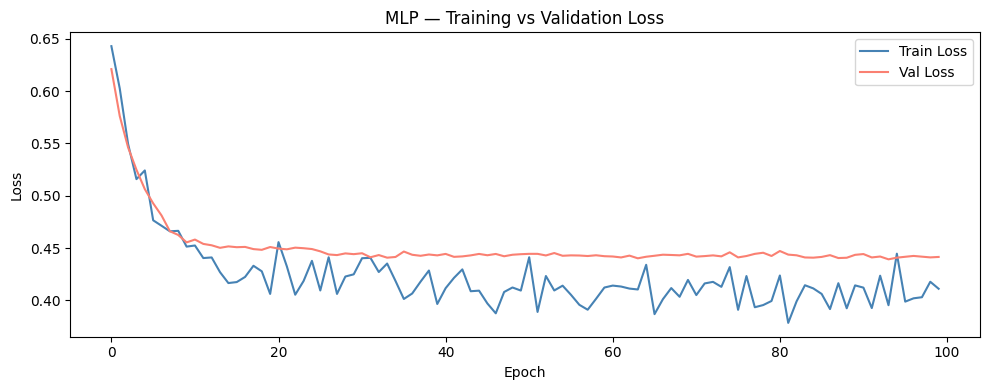

         MLP RESULTS
Accuracy  : 81.56%
Precision : 86.00%
Recall    : 62.32%
F1 Score  : 72.27%
AUC-ROC   : 0.8436

Classification Report:
              precision    recall  f1-score   support

Not Survived       0.80      0.94      0.86       110
    Survived       0.86      0.62      0.72        69

    accuracy                           0.82       179
   macro avg       0.83      0.78      0.79       179
weighted avg       0.82      0.82      0.81       179



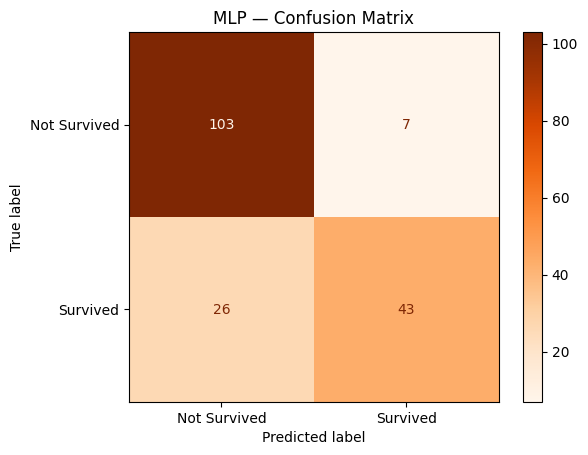

In [29]:
# ── Learning Curves ──────────────────────────────────────
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss', color='steelblue')
plt.plot(val_losses,   label='Val Loss',   color='salmon')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('MLP — Training vs Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()

# ── Evaluation ───────────────────────────────────────────
model.eval()
with torch.no_grad():
    y_proba_tensor = model(X_test_tensor).squeeze()
    y_pred_tensor  = (y_proba_tensor >= 0.5).float()

y_pred_mlp  = y_pred_tensor.numpy()
y_proba_mlp = y_proba_tensor.numpy()

print("=" * 40)
print("         MLP RESULTS")
print("=" * 40)
print(f"Accuracy  : {accuracy_score(y_test, y_pred_mlp)*100:.2f}%")
print(f"Precision : {precision_score(y_test, y_pred_mlp)*100:.2f}%")
print(f"Recall    : {recall_score(y_test, y_pred_mlp)*100:.2f}%")
print(f"F1 Score  : {f1_score(y_test, y_pred_mlp)*100:.2f}%")
print(f"AUC-ROC   : {roc_auc_score(y_test, y_proba_mlp):.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_mlp,
      target_names=['Not Survived','Survived']))

# ── Confusion Matrix ─────────────────────────────────────
cm   = confusion_matrix(y_test, y_pred_mlp)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                   display_labels=['Not Survived','Survived'])
disp.plot(cmap='Oranges')
plt.title('MLP — Confusion Matrix')
plt.show()